In [50]:
# Basic Libraries
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt # we only need pyplot
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
sb.set() # set the default Seaborn style for graphics

In [51]:
MainData = pd.read_csv("Students Social Media Addiction.csv")

In [52]:
MainData

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,In Relationship,2,5
701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4,Single,5,9
702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6,In Relationship,3,7
703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8,Single,2,4


In [53]:
RSstats = pd.DataFrame(MainData[["Relationship_Status","Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night", "Conflicts_Over_Social_Media", "Addicted_Score"]])

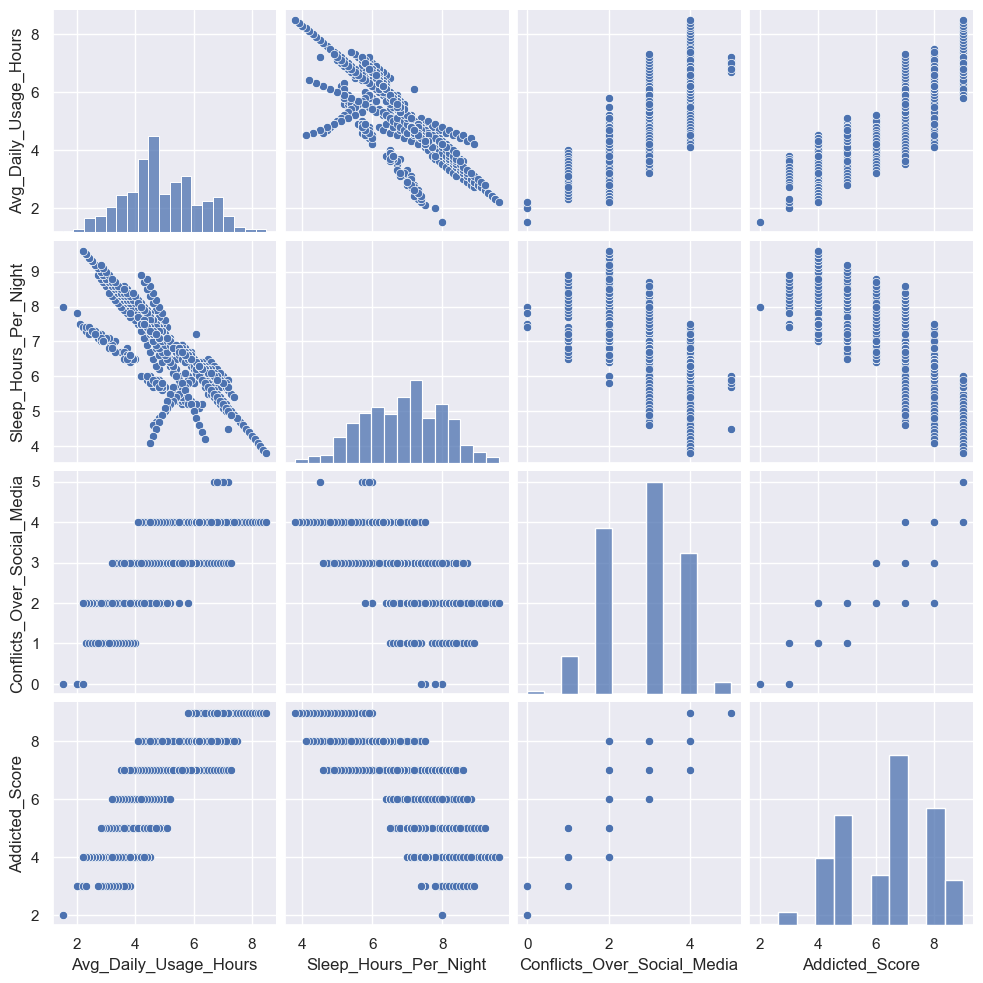

In [54]:
sb.pairplot(data = RSstats)

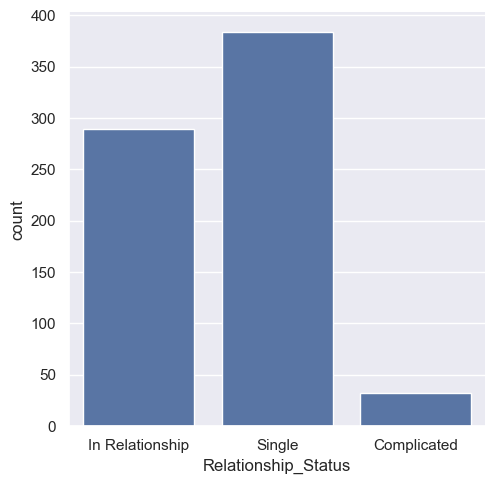

In [55]:
sb.catplot(data = RSstats, x= "Relationship_Status", kind = "count")

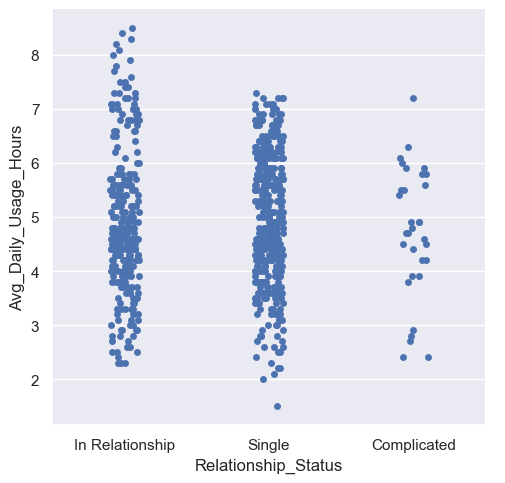

In [56]:
sb.catplot(data = RSstats, x = "Relationship_Status", y = "Avg_Daily_Usage_Hours")

<Axes: xlabel='Relationship_Status', ylabel='Avg_Daily_Usage_Hours'>

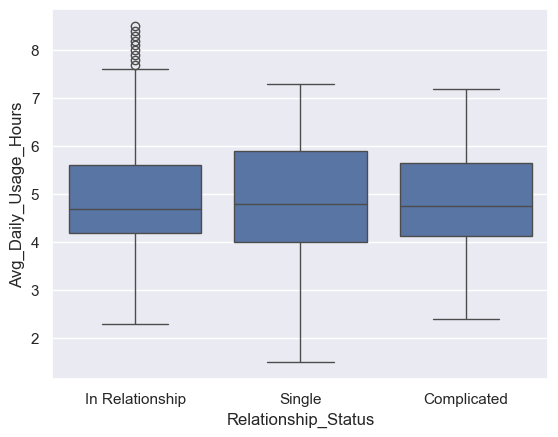

In [57]:
sb.boxplot(data = RSstats, x = "Relationship_Status", y = "Avg_Daily_Usage_Hours")

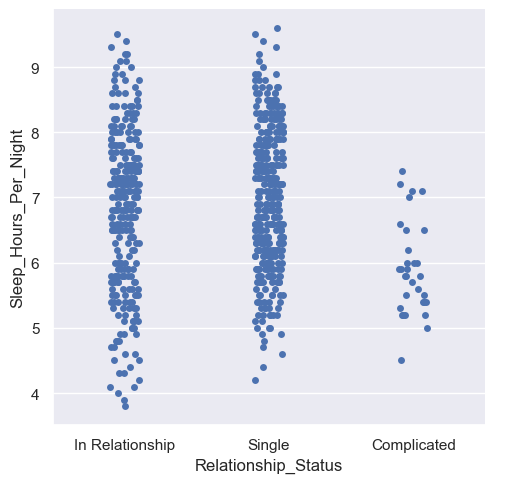

In [58]:
sb.catplot(data = RSstats, x = "Relationship_Status", y = "Sleep_Hours_Per_Night")

<Axes: xlabel='Relationship_Status', ylabel='Sleep_Hours_Per_Night'>

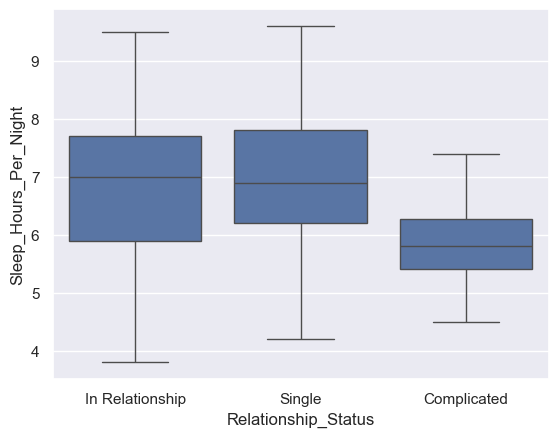

In [59]:
sb.boxplot(data = RSstats, x = "Relationship_Status", y = "Sleep_Hours_Per_Night")

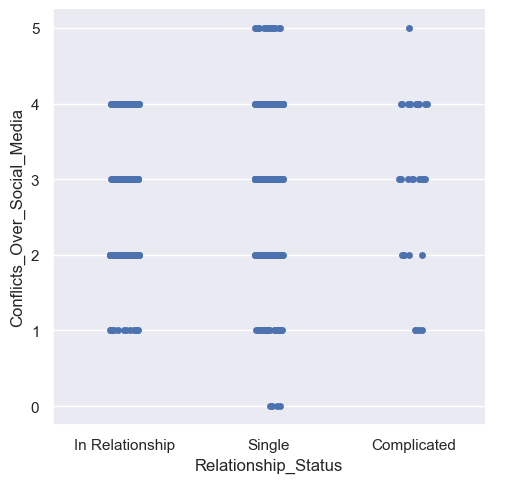

In [60]:
sb.catplot(data = RSstats, x = "Relationship_Status", y = "Conflicts_Over_Social_Media")

<Axes: xlabel='Relationship_Status', ylabel='Conflicts_Over_Social_Media'>

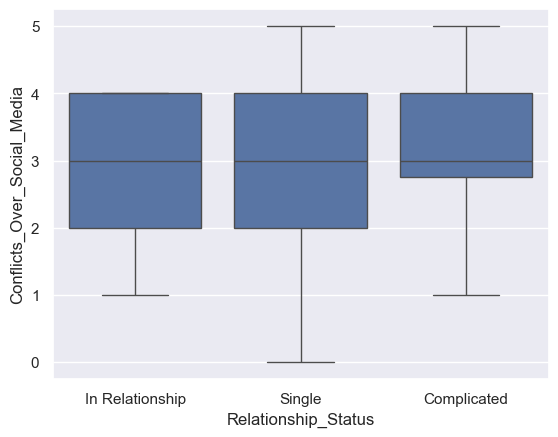

In [61]:
sb.boxplot(data = RSstats, x = "Relationship_Status", y = "Conflicts_Over_Social_Media")

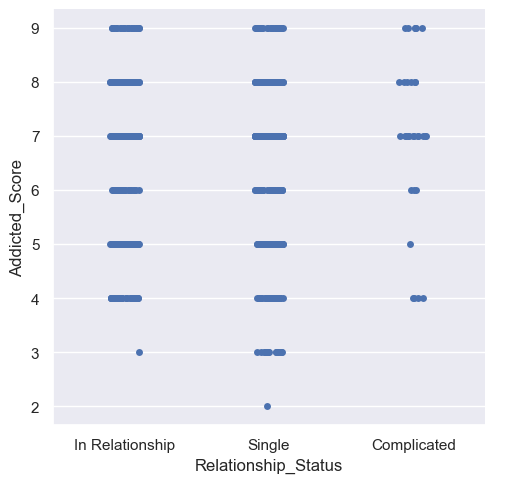

In [62]:
sb.catplot(data = RSstats, x = "Relationship_Status", y = "Addicted_Score")

<Axes: xlabel='Relationship_Status', ylabel='Age'>

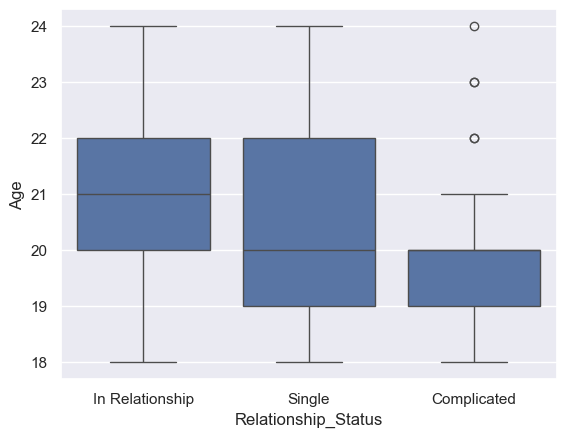

In [63]:
sb.boxplot(data = MainData, x = "Relationship_Status", y = "Age")

In [64]:
RS = pd.DataFrame(MainData[["Relationship_Status", "Academic_Level", "Most_Used_Platform"]])

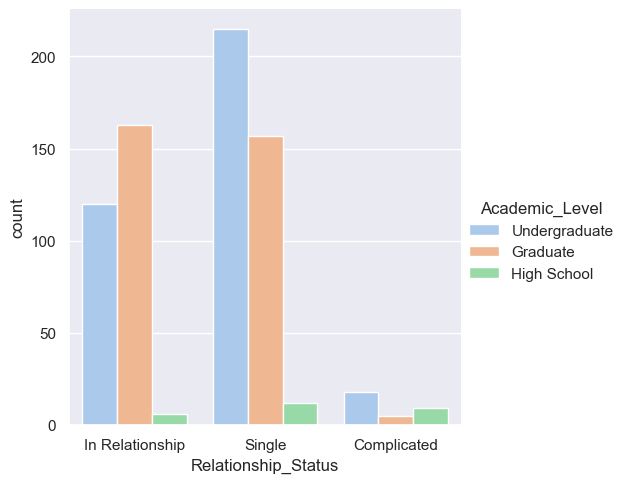

In [65]:
sb.catplot( data = RS, x = "Relationship_Status", hue = "Academic_Level", kind ="count", palette = "pastel")

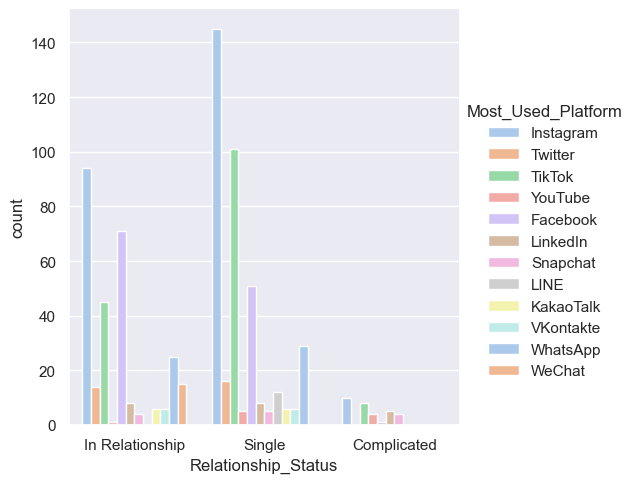

In [66]:
sb.catplot( data = RS, x = "Relationship_Status", hue = "Most_Used_Platform", kind ="count", palette = "pastel")

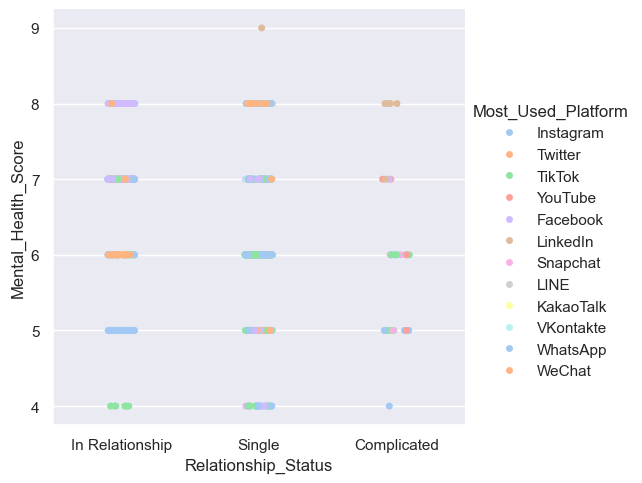

In [67]:
sb.catplot( data = MainData, x = "Relationship_Status", y = "Mental_Health_Score", hue = "Most_Used_Platform", palette = "pastel")

In [74]:
CleanedData = MainData.copy()

In [75]:
CleanedData["Relationship_Status"] = CleanedData["Relationship_Status"].astype("category")

In [98]:
CleanedData

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,NaN,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,In Relationship,2,5
701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4,Single,5,9
702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6,In Relationship,3,7
703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8,Single,2,4


In [77]:
print(CleanedData["Relationship_Status"])

0      In Relationship
1               Single
2          Complicated
3               Single
4      In Relationship
            ...       
700    In Relationship
701             Single
702    In Relationship
703             Single
704             Single
Name: Relationship_Status, Length: 705, dtype: category
Categories (3, object): ['Complicated', 'In Relationship', 'Single']


In [78]:
CleanedData["Relationship_Status"] = CleanedData["Relationship_Status"].cat.remove_categories("Complicated")

In [79]:
print(CleanedData["Relationship_Status"])

0      In Relationship
1               Single
2                  NaN
3               Single
4      In Relationship
            ...       
700    In Relationship
701             Single
702    In Relationship
703             Single
704             Single
Name: Relationship_Status, Length: 705, dtype: category
Categories (2, object): ['In Relationship', 'Single']


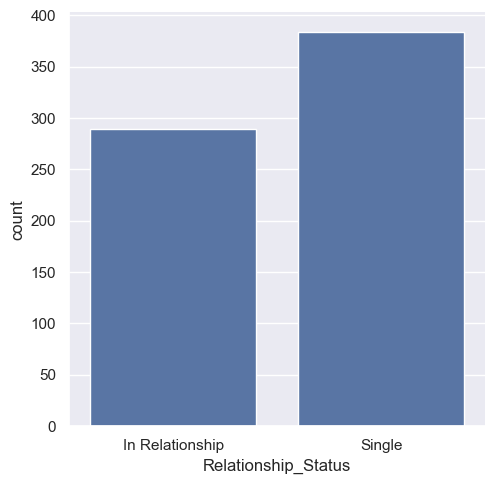

In [80]:
sb.catplot(data = CleanedData, x= "Relationship_Status", kind = "count")

In [81]:
ohe = OneHotEncoder(handle_unknown = "ignore", sparse_output = False).set_output(transform='pandas')
#handle unkown s to not take unknown data into the encoder
#We are using panda output not sparse
CleanedData.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,NaN,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [82]:
ohetransform1 = ohe.fit_transform(CleanedData[["Relationship_Status"]])

In [83]:
ohetransform1

,Relationship_Status_In Relationship,Relationship_Status_Single,Relationship_Status_nan
0,1.0,0.0,0.0
1,0.0,1.0,0.0
2,0.0,0.0,1.0
3,0.0,1.0,0.0
4,1.0,0.0,0.0
...,...,...,...
700,1.0,0.0,0.0
701,0.0,1.0,0.0
702,1.0,0.0,0.0
703,0.0,1.0,0.0
